In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import TSMixerModel
from darts.metrics import rmse, r2_score
import torch

# 1. Load and drop the integer Time column
df = pd.read_csv('/content/junction_data_race_course.csv')
df = df.drop(columns=['Time'])

# 2. Convert integer index → DatetimeIndex (seconds since 2025-01-01)
start = pd.Timestamp('2025-01-01 00:00:00')
df.index = start + pd.to_timedelta(df.index, unit='s')  # seconds → timedelta

df = df.resample("5T").mean()  # Resample to 1-minute intervals

# 3. Remove last 5% of data as validation (`val`)
val_size = int(0.05 * len(df))
train_test_df, val_df = df[:-val_size], df[-val_size:]

# 4. Convert to multivariate TimeSeries
ts_all = TimeSeries.from_dataframe(train_test_df, value_cols=list(df.columns), freq='s')
val_ts = TimeSeries.from_dataframe(val_df, value_cols=list(df.columns), freq='s')

# 5. Train/Test split (70% train, 30% test)
split_idx = int(0.7 * len(ts_all))
train_ts, test_ts = ts_all[:split_idx], ts_all[split_idx:]

# 6. Scale the series
scaler = Scaler()
train_s = scaler.fit_transform(train_ts)
test_s = scaler.transform(test_ts)
val_s = scaler.transform(val_ts)  # Scale validation set

# 7. Instantiate TSMixerModel
model = TSMixerModel(
    input_chunk_length=10,     # model “sees” 10 past time steps
    output_chunk_length=val_size,  # forecasts as many steps as `val`
    hidden_size=64,
    ff_size=64,
    num_blocks=3,
    dropout=0.1,
    random_state=42,
    n_epochs=500,
    pl_trainer_kwargs={        # instruct PyTorch Lightning to use GPU 0
        "accelerator": "gpu",
        "devices": [0]
    }
)

# 8. Fit the model
model.fit(series=train_s, verbose=True)

# 9. Forecast for as many steps as `val`
forecast_s = model.predict(n=val_size, series=train_s)

# 10. Inverse scale back to original units
forecast = scaler.inverse_transform(forecast_s)

# 11. Evaluate on validation set
print("Multivariate RMSE:", rmse(val_ts, forecast))
print("Multivariate R²  :", r2_score(val_ts, forecast))




<ipython-input-46-9db62bd3a9ae>:18: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample("5T").mean()  # Resample to 1-minute intervals
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | criterion           | MSELoss          | 0      | train
1 | train_criterion     | MSELoss          | 0      | train
2 | val_criterion       | MSELoss          | 0      | train
3 | train_metrics       | MetricCollection | 0      | train
4 | val_metrics         | MetricCollection | 0      | tr

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Multivariate RMSE: nan
Multivariate R²  : nan


/usr/local/lib/python3.11/dist-packages/darts/metrics/metrics.py:1406: RuntimeWarning: Mean of empty slice
  return np.nanmean(
/usr/local/lib/python3.11/dist-packages/darts/metrics/metrics.py:374: RuntimeWarning: Mean of empty slice
  vals = component_reduction(vals, axis=COMP_AX)
/usr/local/lib/python3.11/dist-packages/darts/metrics/metrics.py:2928: RuntimeWarning: Mean of empty slice
  y_hat = np.nanmean(y_true, axis=TIME_AX)
/usr/local/lib/python3.11/dist-packages/darts/metrics/metrics.py:2930: RuntimeWarning: invalid value encountered in divide
  return 1 - ss_errors / ss_tot


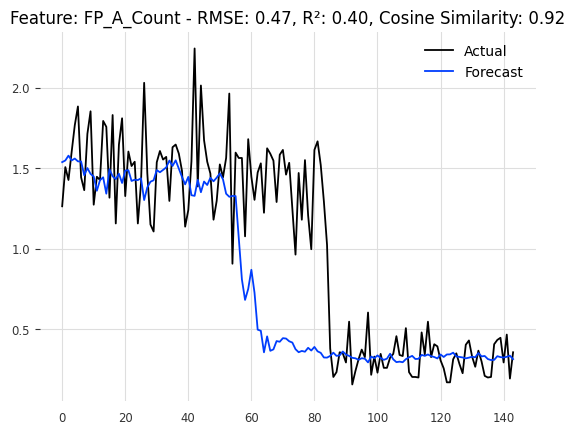

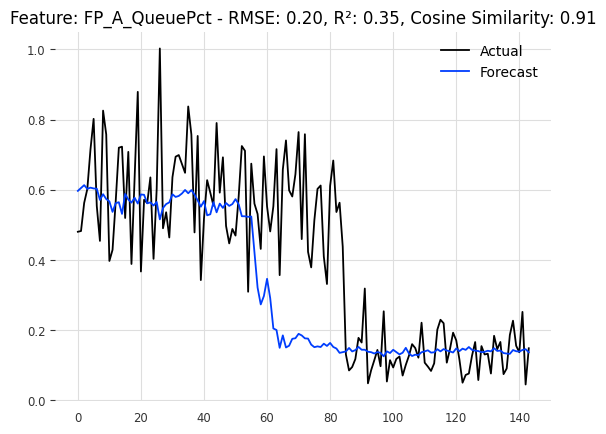

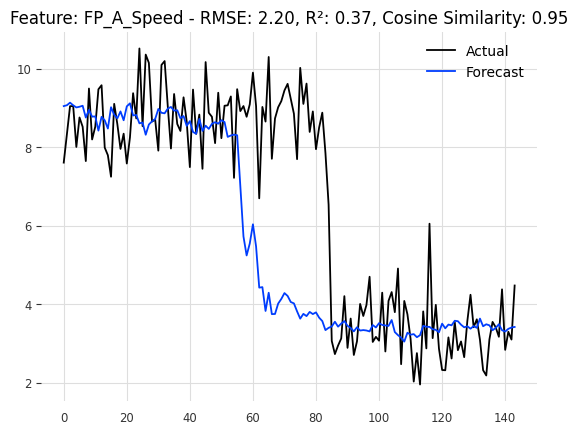

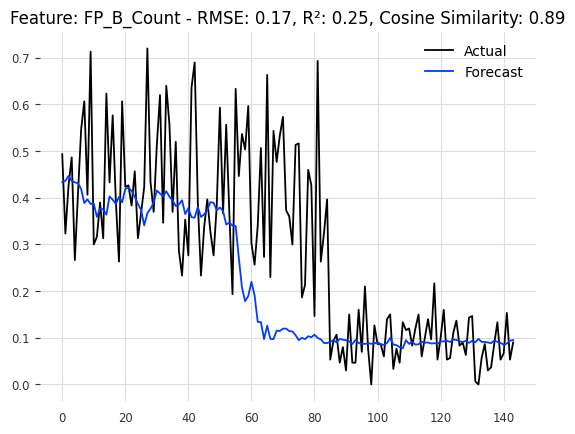

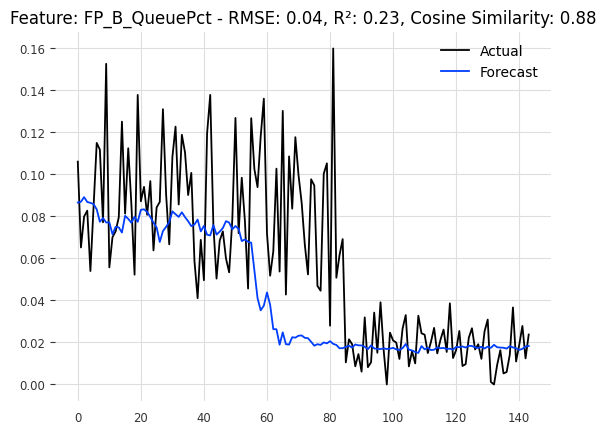

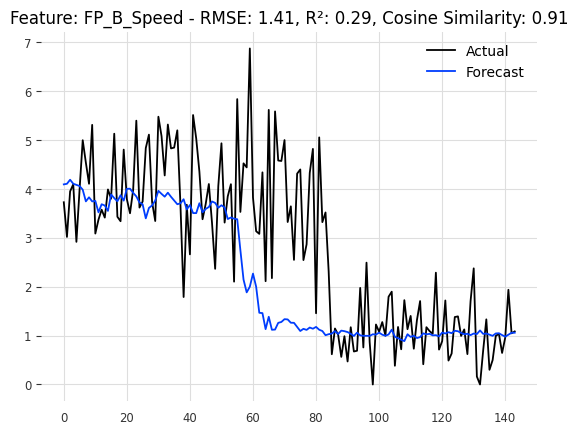

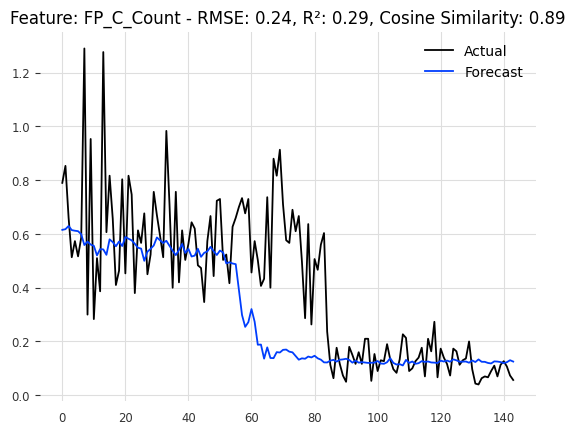

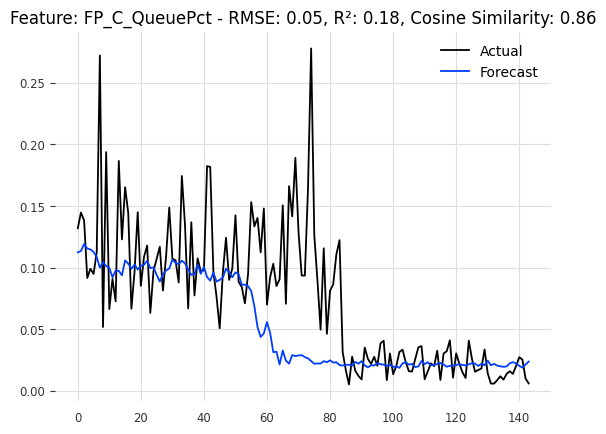

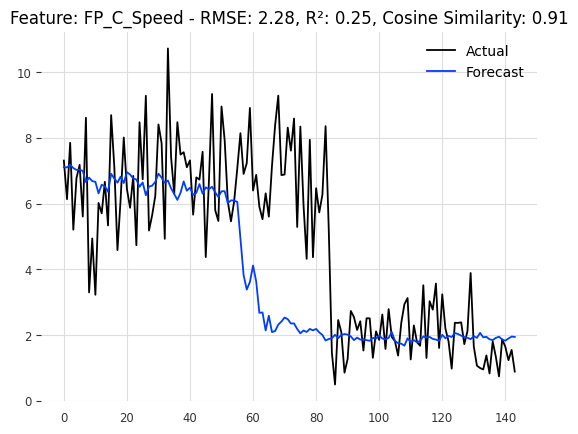

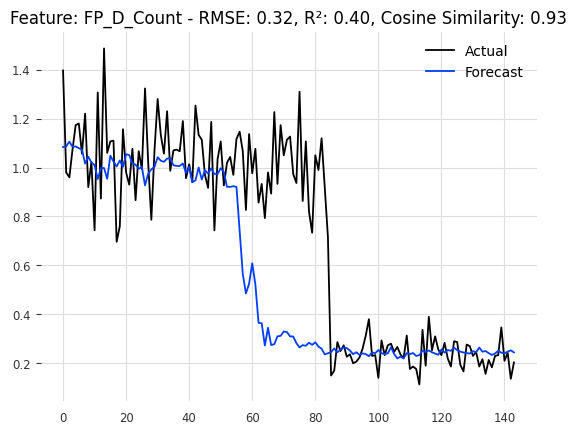

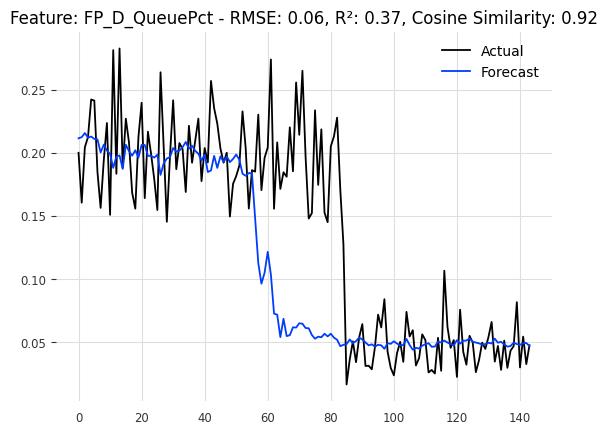

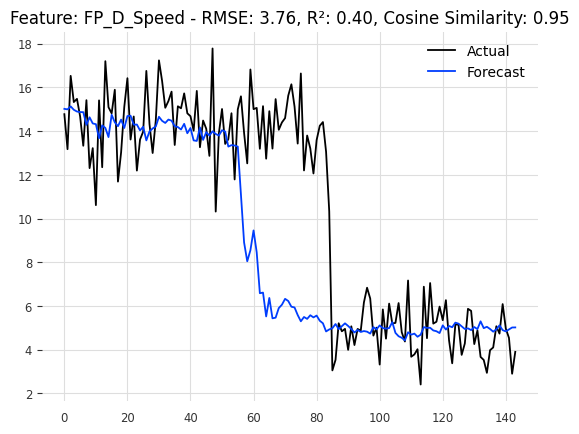

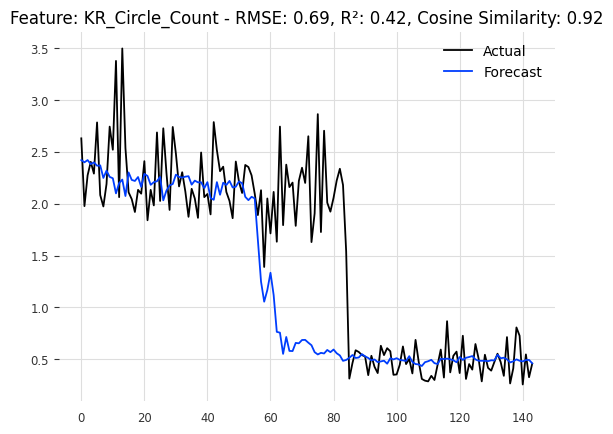

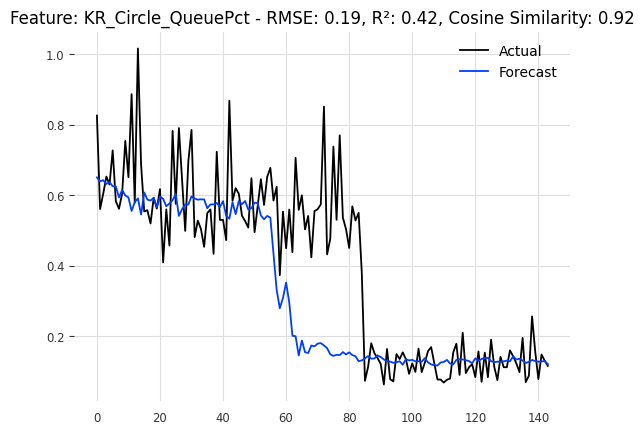

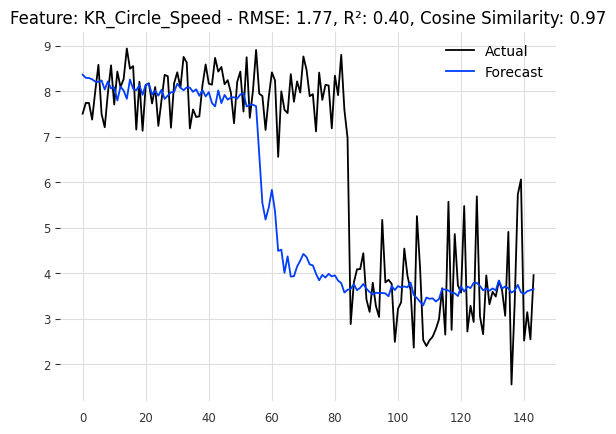

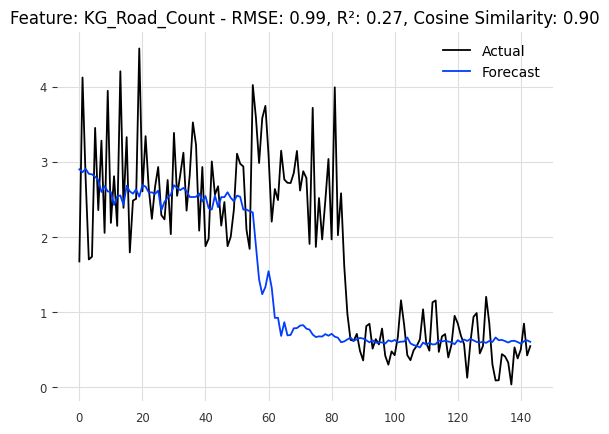

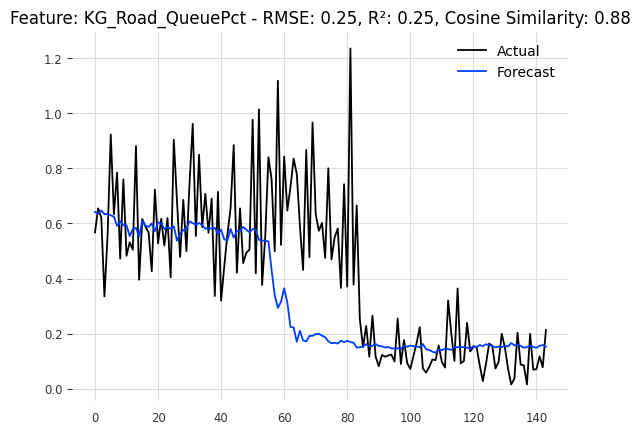

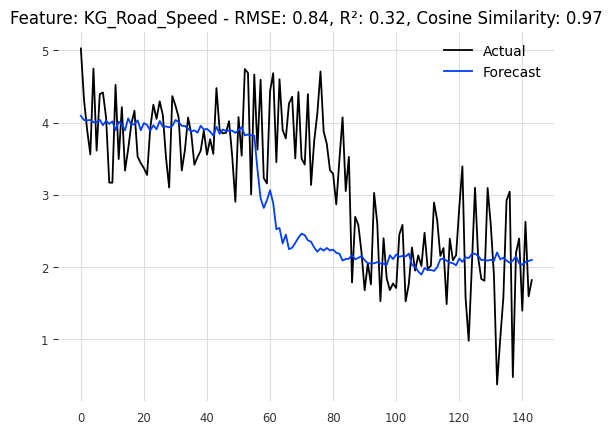

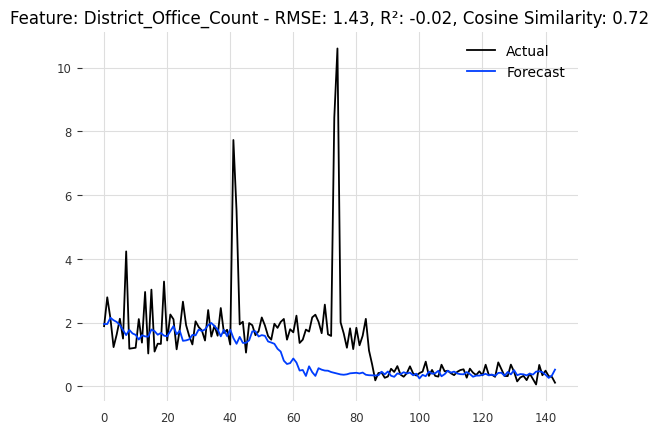

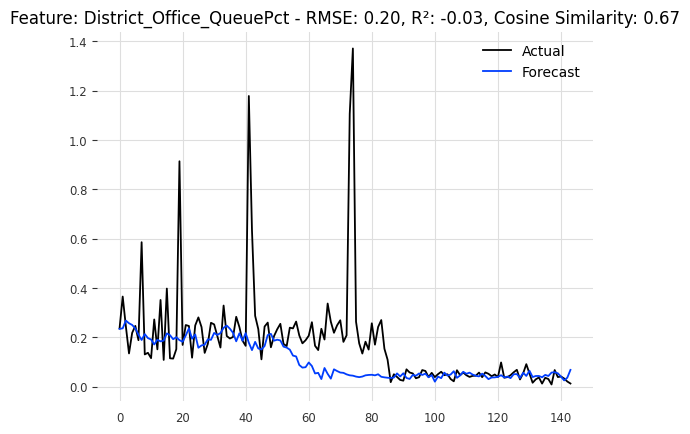

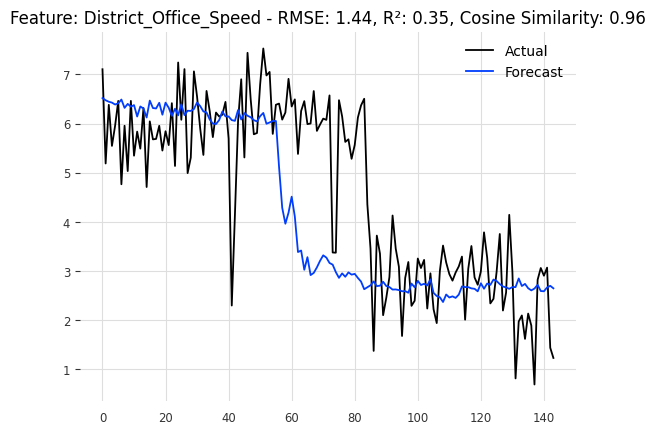

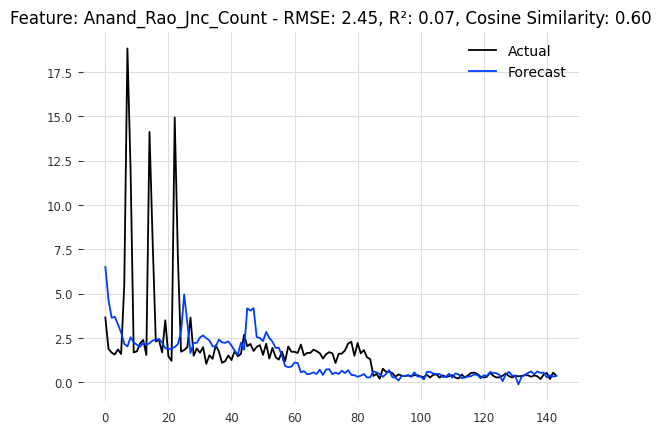

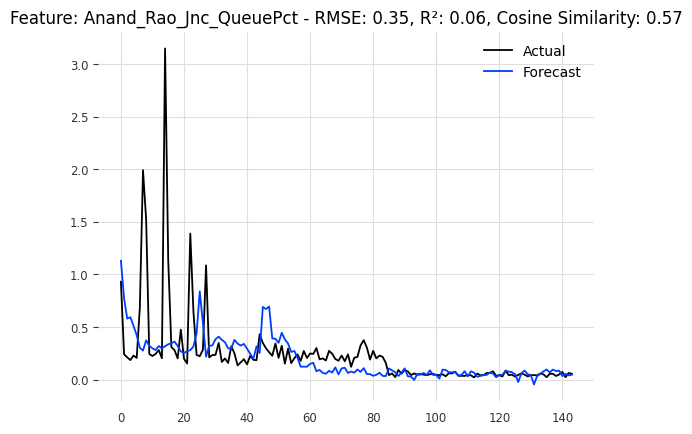

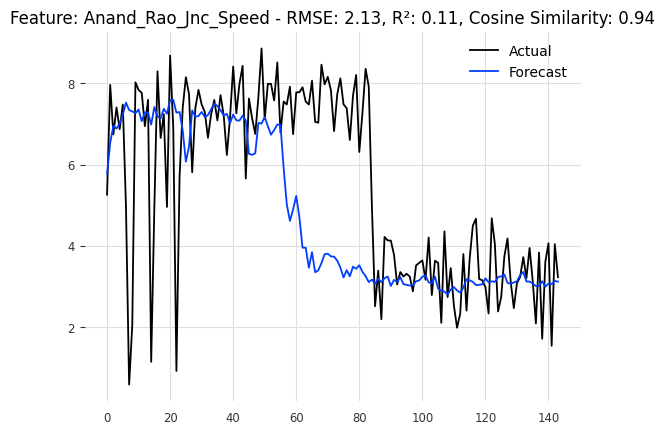

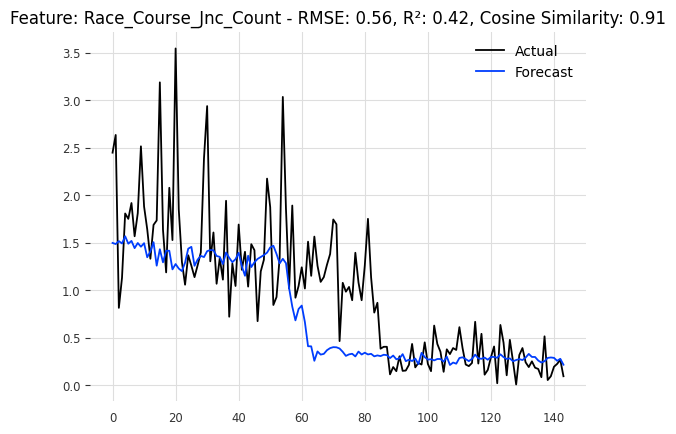

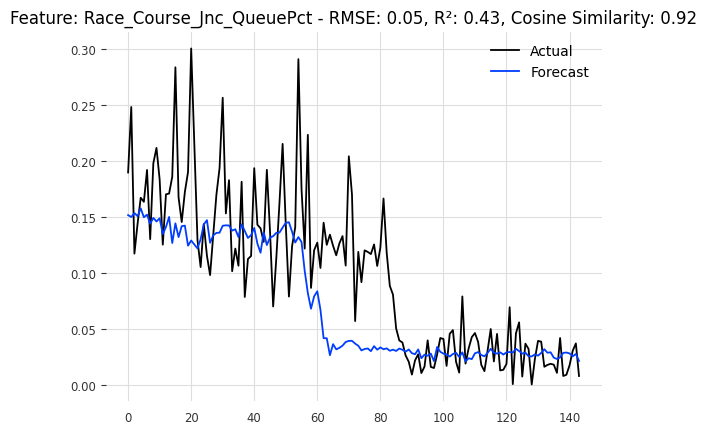

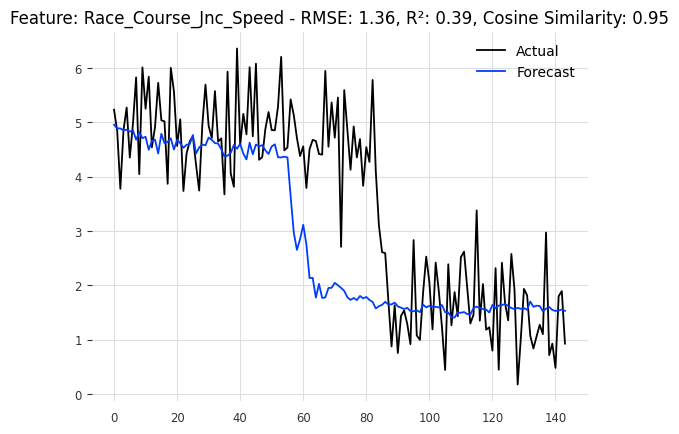

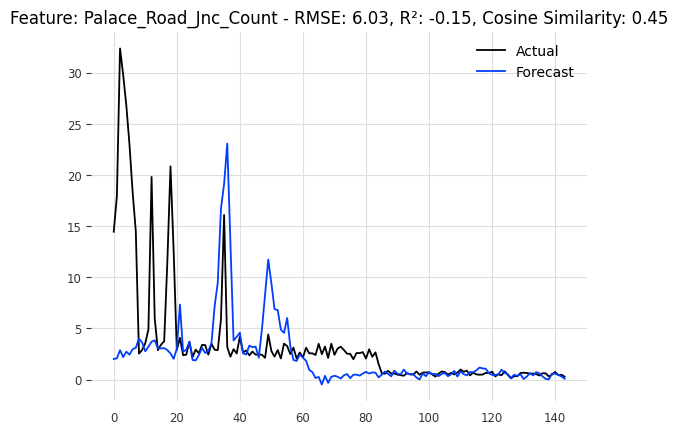

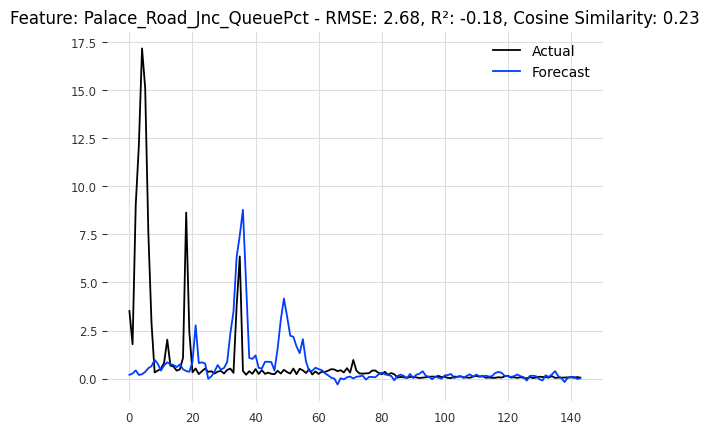

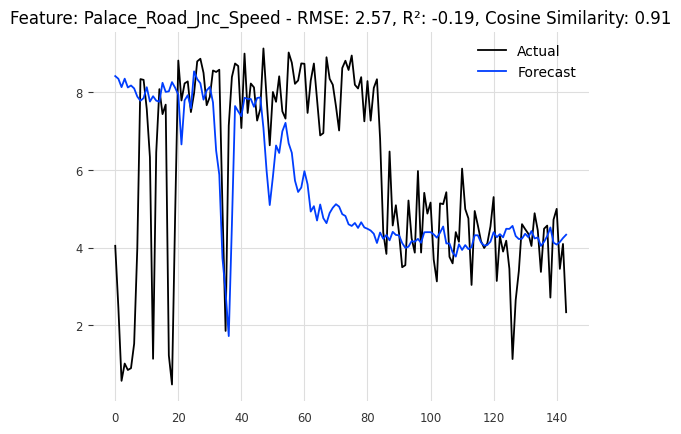

Average RMSE: 1.24
Average R²: 0.24
Average Cosine Similarity: 0.84


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

df1 = val_ts.to_dataframe().reset_index(drop=True)
df2 = forecast.to_dataframe().reset_index(drop=True)

avg_rmse = 0
avg_r2 = 0
avg_cosine = 0

for i in range(df1.shape[1]):
  # Calculate metrics
  rmse_val = np.sqrt(mean_squared_error(df1.iloc[:, i], df2.iloc[:, i]))
  r2_val = r2_score(df1.iloc[:, i], df2.iloc[:, i])

  # Reshape for cosine similarity (ensure 2D arrays)
  actual_data = df1.iloc[:, i].values.reshape(1, -1)  # Convert to NumPy array using .values first
  forecast_data = df2.iloc[:, i].values.reshape(1, -1) # Convert to NumPy array using .values first
  cosine_sim = cosine_similarity(actual_data, forecast_data)[0][0]

  # Plotting with metrics in title
  plt.plot(df1.iloc[:, i], label="Actual")
  plt.plot(df2.iloc[:, i], label="Forecast")
  plt.title(f"Feature: {df1.columns[i]} - RMSE: {rmse_val:.2f}, R²: {r2_val:.2f}, Cosine Similarity: {cosine_sim:.2f}")
  plt.legend()
  plt.show()

  avg_rmse += rmse_val
  avg_r2 += r2_val
  avg_cosine += cosine_sim

avg_rmse /= df1.shape[1]
avg_r2 /= df1.shape[1]
avg_cosine /= df1.shape[1]

print(f"Average RMSE: {avg_rmse:.2f}")
print(f"Average R²: {avg_r2:.2f}")
print(f"Average Cosine Similarity: {avg_cosine:.2f}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

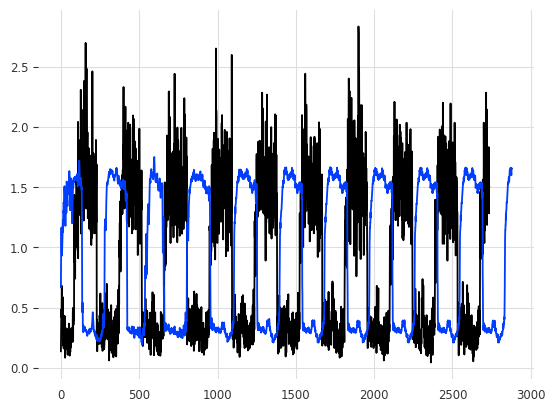

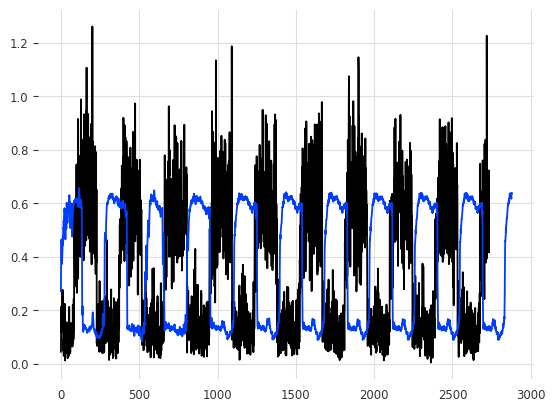

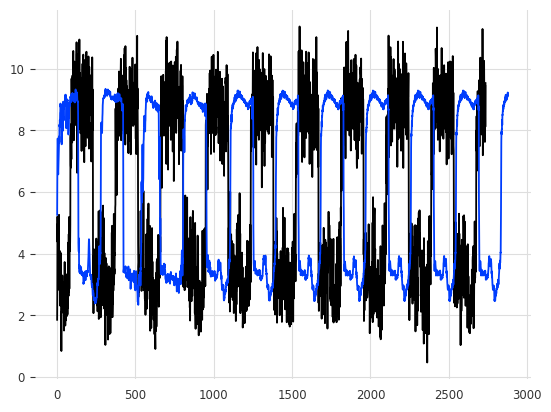

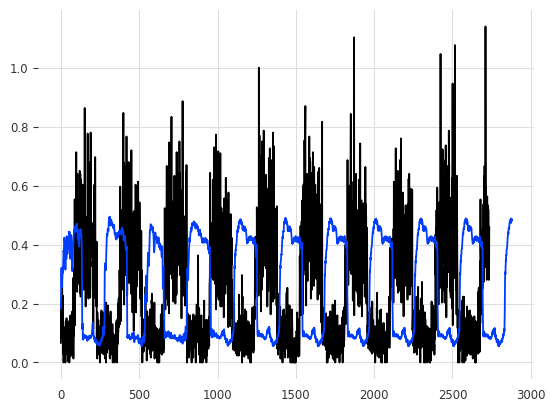

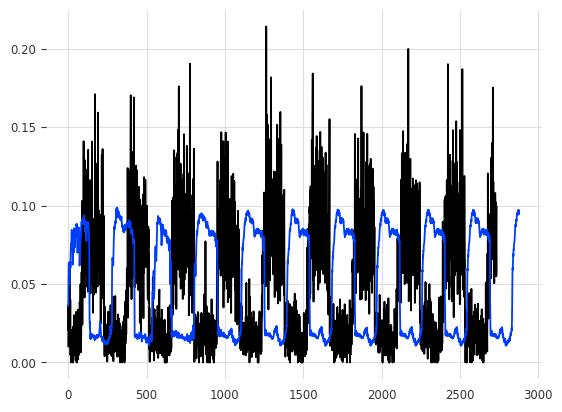

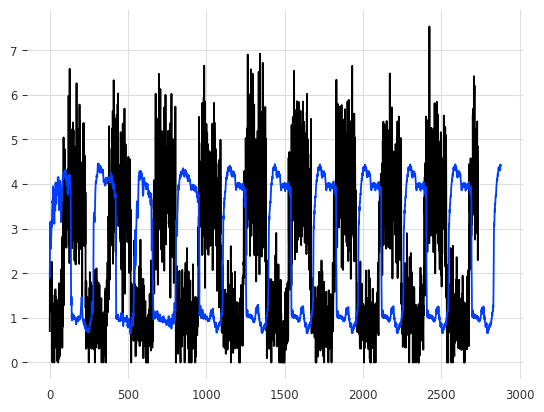

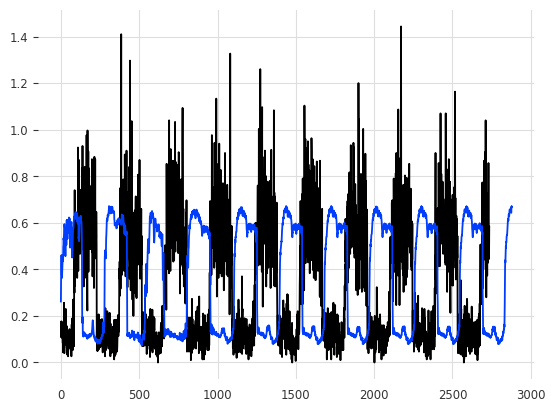

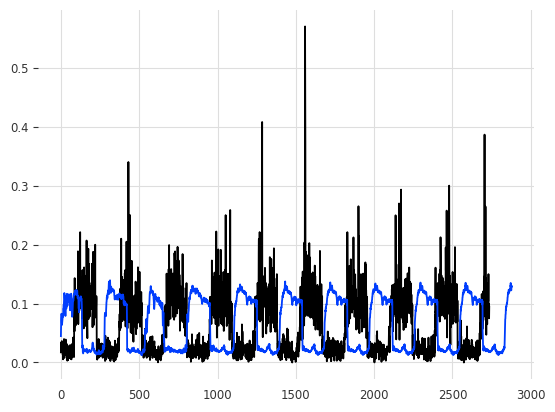

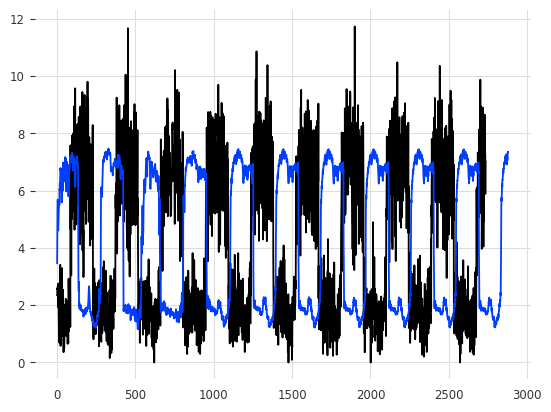

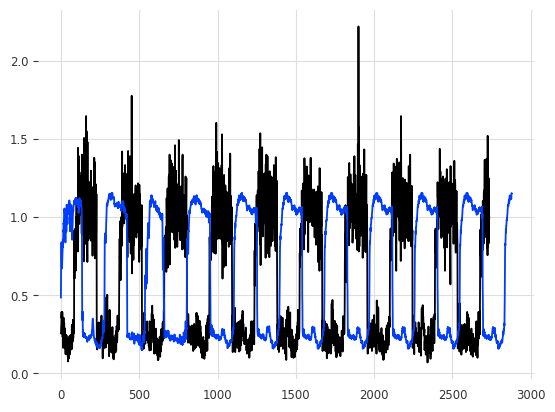

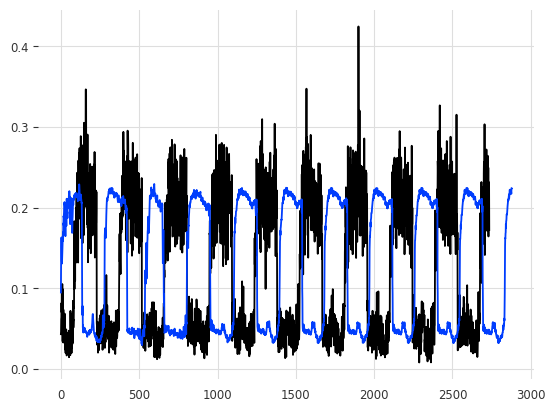

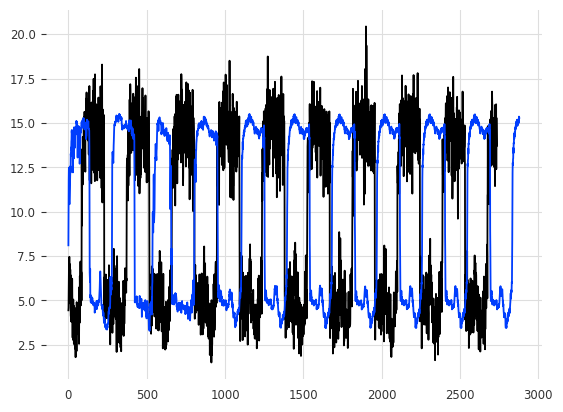

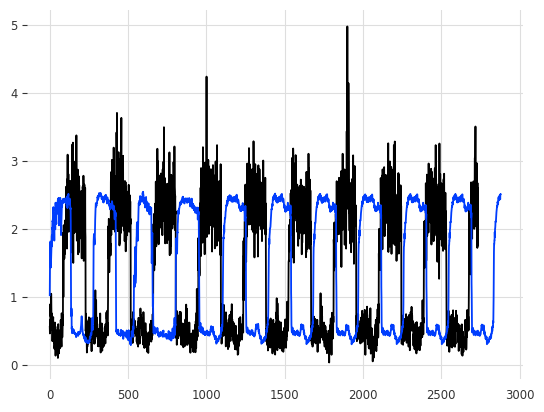

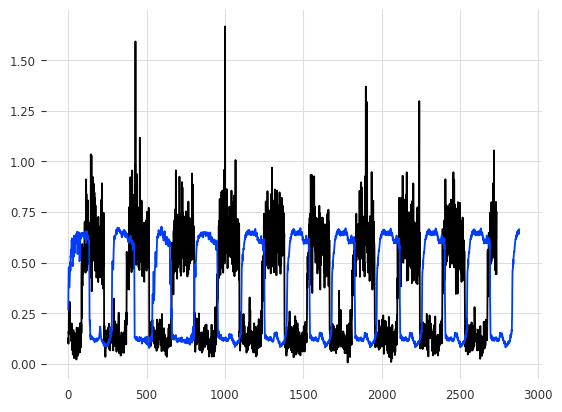

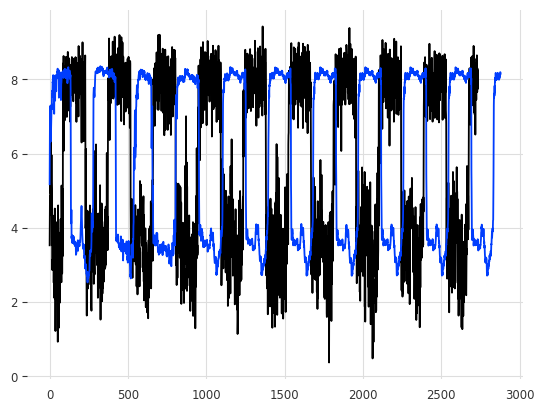

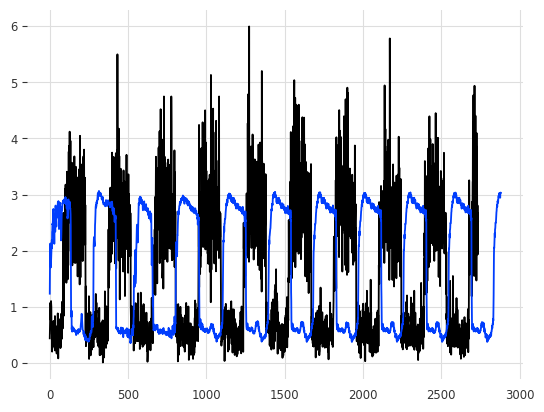

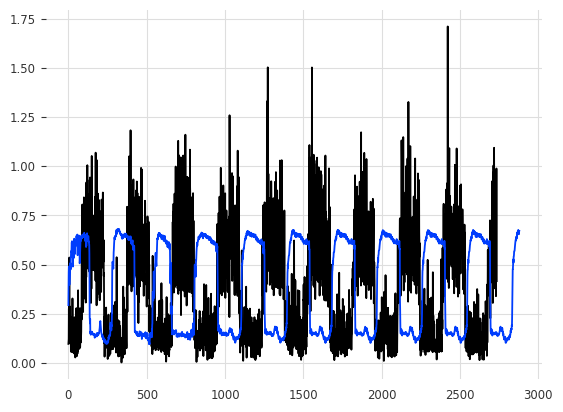

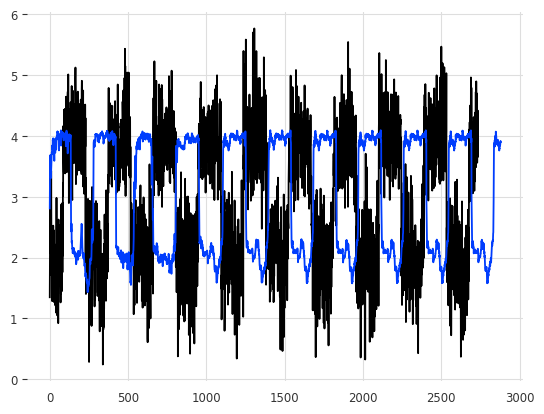

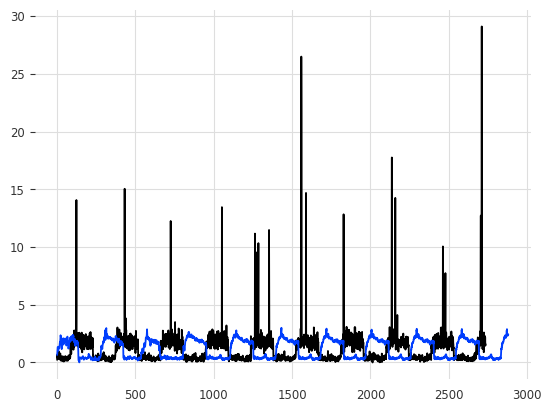

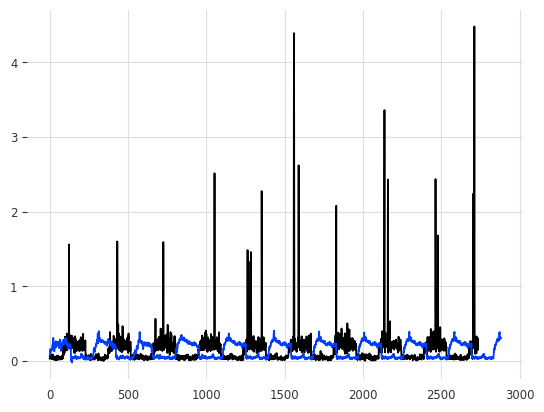

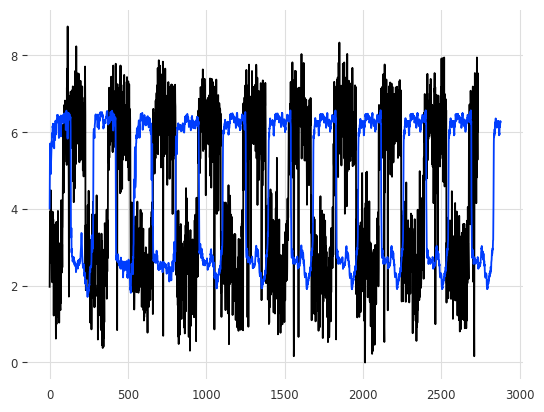

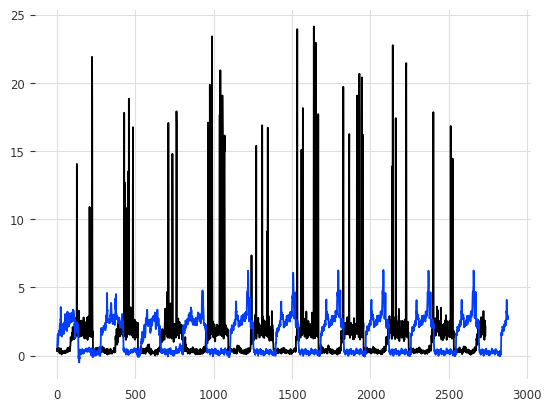

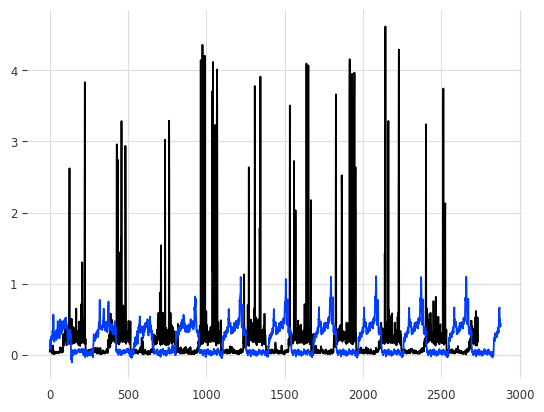

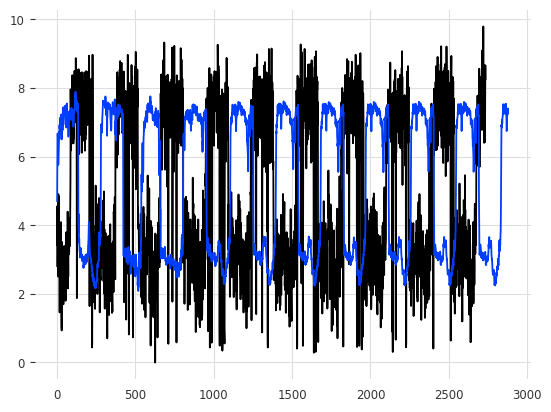

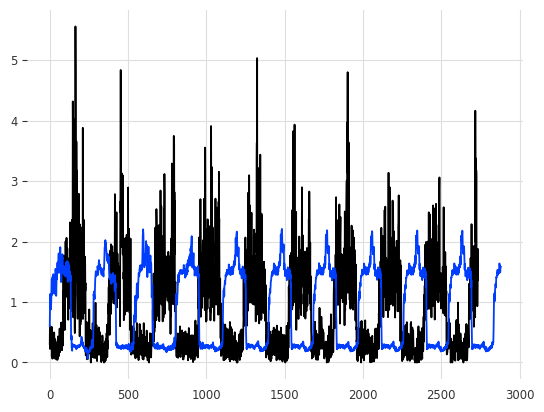

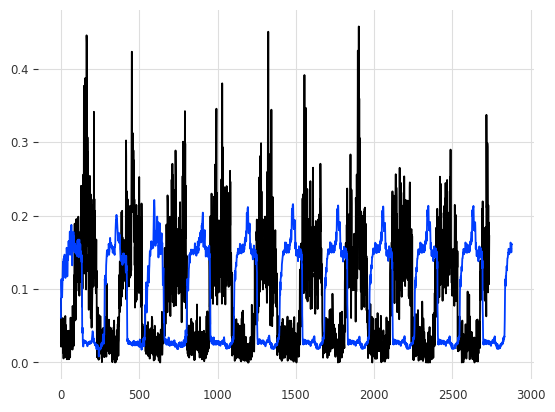

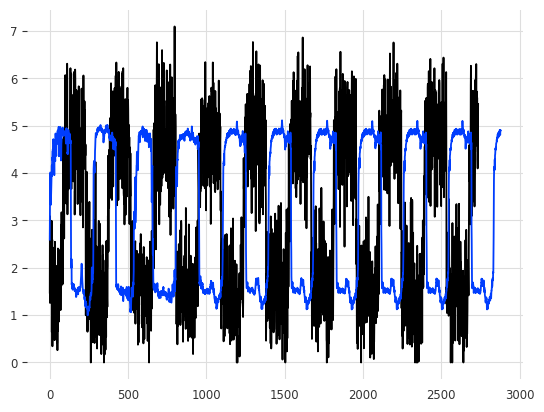

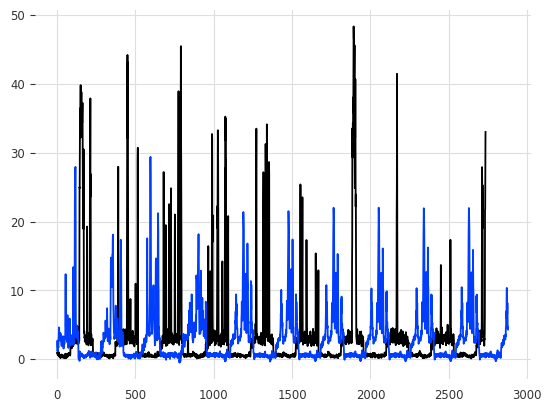

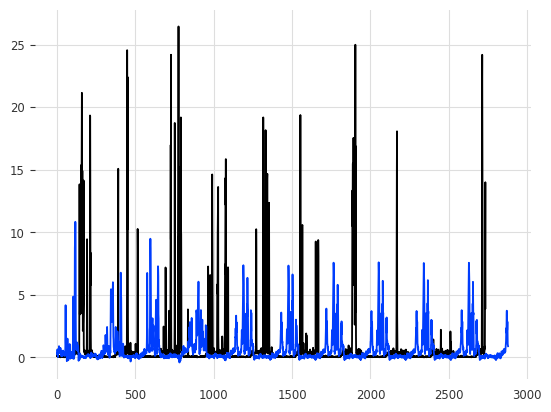

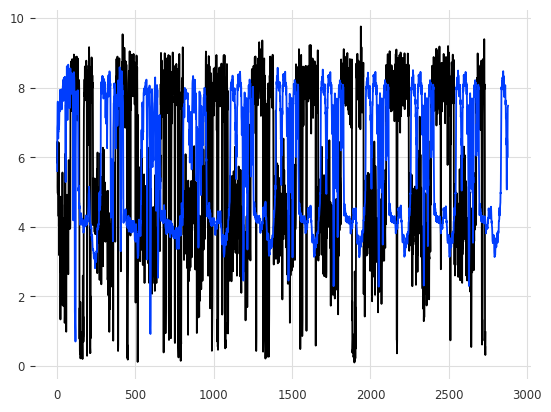

In [ ]:
forecast_s = model.predict(n=2880, series=ts_all)

tsall = ts_all.to_dataframe().reset_index(drop=True)
forecast = scaler.inverse_transform(forecast_s)
forecast = forecast.to_dataframe().reset_index(drop=True)

for i in range(tsall.shape[1]):
  plt.plot(tsall.iloc[:, i], label="Actual")
  plt.plot(forecast.iloc[:, i], label="Forecast")
  plt.show()